Project_2

In [2]:
import pandas as pd
from pathlib import Path

# Project root is one level up from notebooks/
project_root = Path.cwd().parent
data_dir = project_root / "data"

# Load just 2011 first, to see what one file looks like.
df_2011 = pd.read_csv(data_dir / "gt_2011.csv")

print("Shape:", df_2011.shape)
print("\nColumns:", list(df_2011.columns))
print("\nFirst rows:")
print(df_2011.head())

Shape: (7411, 11)

Columns: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']

First rows:
       AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP  \
0  4.5878  1018.7  83.675  3.5758  23.979  1086.2  549.83  134.67  11.898   
1  4.2932  1018.3  84.235  3.5709  23.951  1086.1  550.05  134.67  11.892   
2  3.9045  1018.4  84.858  3.5828  23.990  1086.5  550.19  135.10  12.042   
3  3.7436  1018.3  85.434  3.5808  23.911  1086.5  550.17  135.03  11.990   
4  3.7516  1017.8  85.182  3.5781  23.917  1085.9  550.00  134.67  11.910   

        CO     NOX  
0  0.32663  81.952  
1  0.44784  82.377  
2  0.45144  83.776  
3  0.23107  82.505  
4  0.26747  82.028  


Concatenate all five yearly files in chronological order into one dataset, and audit it.

In [3]:
# Load all five years IN ORDER and tag each with its year.
years = [2011, 2012, 2013, 2014, 2015]
frames = []

for year in years:
    df_year = pd.read_csv(data_dir / f"gt_{year}.csv")
    df_year["year"] = year          # tag provenance for the chronological split
    frames.append(df_year)
    print(f"{year}: {df_year.shape[0]} rows")

# Concatenate in order. ignore_index=True renumbers rows 0..N sequentially,
# preserving the chronological stacking (2011 first, 2015 last).
df = pd.concat(frames, ignore_index=True)

print("\nCombined shape:", df.shape)
print("Rows per year:\n", df["year"].value_counts().sort_index())

2011: 7411 rows
2012: 7628 rows
2013: 7152 rows
2014: 7158 rows
2015: 7384 rows

Combined shape: (36733, 12)
Rows per year:
 year
2011    7411
2012    7628
2013    7152
2014    7158
2015    7384
Name: count, dtype: int64


audit the combined data

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget (TEY) summary:")
print(df["TEY"].describe())

Missing values per column:
AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
year    0
dtype: int64

Duplicate rows: 7

Data types:
AT      float64
AP      float64
AH      float64
AFDP    float64
GTEP    float64
TIT     float64
TAT     float64
TEY     float64
CDP     float64
CO      float64
NOX     float64
year      int64
dtype: object

Target (TEY) summary:
count    36733.000000
mean       133.506404
std         15.618634
min        100.020000
25%        124.450000
50%        133.730000
75%        144.080000
max        179.500000
Name: TEY, dtype: float64


In [5]:
print(df["TEY"].describe())
print("\nMean:", round(df["TEY"].mean(), 2))
print("Median:", round(df["TEY"].median(), 2))
print("Min:", round(df["TEY"].min(), 2))
print("Max:", round(df["TEY"].max(), 2))

count    36733.000000
mean       133.506404
std         15.618634
min        100.020000
25%        124.450000
50%        133.730000
75%        144.080000
max        179.500000
Name: TEY, dtype: float64

Mean: 133.51
Median: 133.73
Min: 100.02
Max: 179.5


Regression EDA
Understand how each sensor relates to TEY, resolve the CO/NOX leakage question, and identify feature-engineering opportunities.

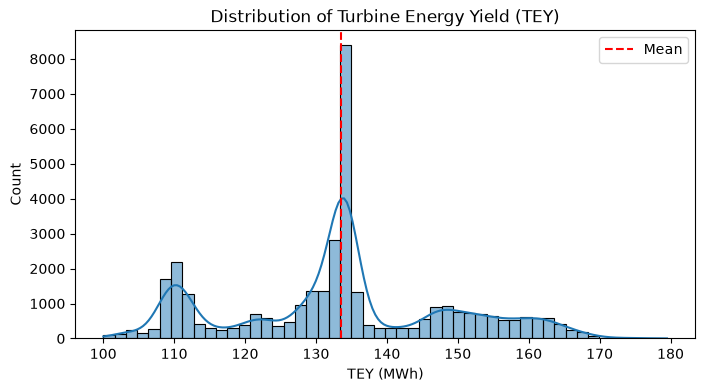

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df["TEY"], bins=50, kde=True)
plt.axvline(df["TEY"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Distribution of Turbine Energy Yield (TEY)")
plt.xlabel("TEY (MWh)")
plt.legend()
plt.show()

Correlation with the target (the key regression view)

Correlation of each feature with TEY:
TEY     1.000000
CDP     0.988778
GTEP    0.964127
TIT     0.910297
AFDP    0.665483
AP      0.118224
year   -0.029414
AT     -0.091152
NOX    -0.116127
AH     -0.137360
CO     -0.569813
TAT    -0.682396
Name: TEY, dtype: float64


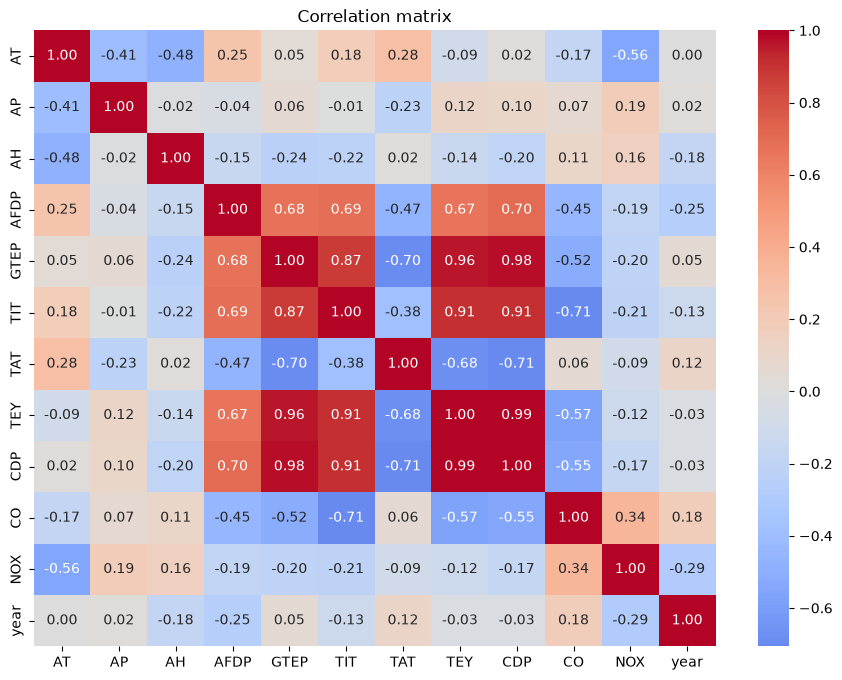

In [7]:
# Correlation of every column with TEY, sorted.
correlations = df.corr()["TEY"].sort_values(ascending=False)
print("Correlation of each feature with TEY:")
print(correlations)

# Heatmap of the full correlation matrix.
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation matrix")
plt.show()

Scatter plots of the strongest predictors vs TEY

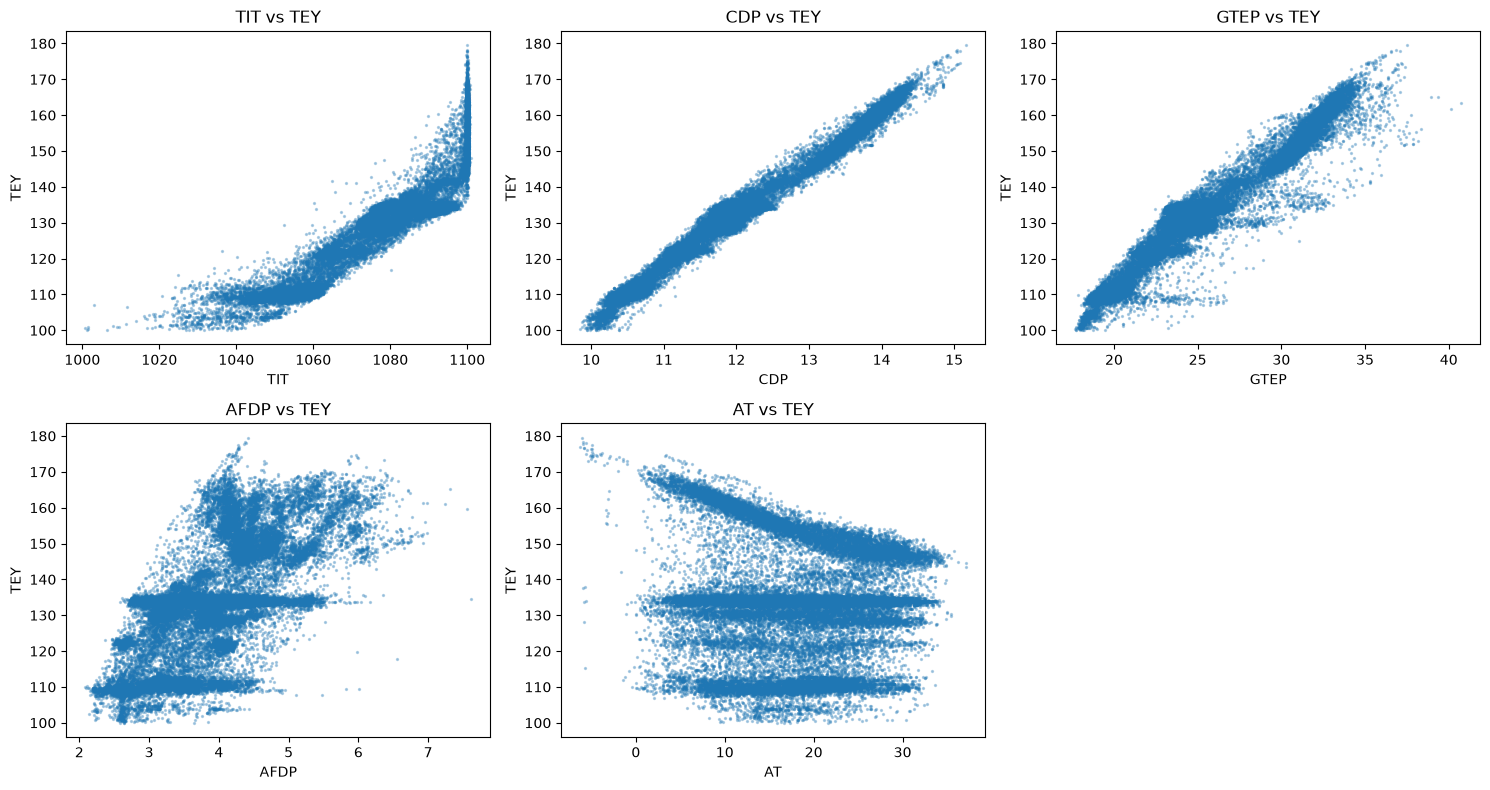

In [8]:
# The operational sensors most physically linked to energy yield.
key_sensors = ["TIT", "CDP", "GTEP", "AFDP", "AT"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, sensor in zip(axes.flatten(), key_sensors):
    ax.scatter(df[sensor], df["TEY"], s=2, alpha=0.3)
    ax.set_xlabel(sensor)
    ax.set_ylabel("TEY")
    ax.set_title(f"{sensor} vs TEY")
axes.flatten()[-1].axis("off")   # hide the empty 6th panel
plt.tight_layout()
plt.show()

The CO/NOX leakage question

In [9]:
print("Correlation of emissions with TEY:")
print(df[["CO", "NOX", "TEY"]].corr()["TEY"])

Correlation of emissions with TEY:
CO    -0.569813
NOX   -0.116127
TEY    1.000000
Name: TEY, dtype: float64


the split

In [10]:
# Operational sensors only — CO/NOX dropped (leakage), year is a tag not a feature.
feature_columns = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP"]
target_column = "TEY"

# 2015 is the FINAL test set — untouched until the very end (like Project 1's test set).
dev_df  = df[df["year"].isin([2011, 2012, 2013, 2014])].reset_index(drop=True)
test_df = df[df["year"] == 2015].reset_index(drop=True)

X_dev,  y_dev  = dev_df[feature_columns],  dev_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

print("Development set (2011-2014):", X_dev.shape)
print("Final test set  (2015):     ", X_test.shape)

Development set (2011-2014): (29349, 8)
Final test set  (2015):      (7384, 8)


Time-series cross-validation on the development set

In [11]:
from sklearn.model_selection import TimeSeriesSplit

# n_splits=3 gives the expanding-window folds 
# across 2011-2014. Data is already chronological, so folds respect time.
tscv = TimeSeriesSplit(n_splits=3)

# Show what the folds look like (train indices grow, val is the next chunk).
for i, (train_idx, val_idx) in enumerate(tscv.split(X_dev), 1):
    print(f"Fold {i}: train={len(train_idx)} rows, validate={len(val_idx)} rows")

Fold 1: train=7338 rows, validate=7337 rows
Fold 2: train=14675 rows, validate=7337 rows
Fold 3: train=22012 rows, validate=7337 rows


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# All 8 features are numeric — just scale them. 
# A simple pipeline: scaler -> model.
demo_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

# Smoke test: fit on the dev set, confirm it runs and produces predictions.
demo_pipeline.fit(X_dev, y_dev)
sample_preds = demo_pipeline.predict(X_dev[:5])

print("Pipeline works. First 5 predictions:", sample_preds.round(2))
print("Actual values:                       ", y_dev[:5].values.round(2))

Pipeline works. First 5 predictions: [136.21 136.24 137.64 137.23 136.51]
Actual values:                        [134.67 134.67 135.1  135.03 134.67]


In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate

# Regression versions of the models. Note: Regressor, not Classifier.
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

results = []

for name, model in candidate_models.items():
    print("Cross-validating:", name)

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    # TimeSeriesSplit -> honest past-predicts-future validation.
    # Negative scores because sklearn maximises; we negate back to positive.
    scores = cross_validate(
        pipeline, X_dev, y_dev,
        cv=tscv,
        scoring=["neg_root_mean_squared_error",
                 "neg_mean_absolute_error", "r2"],
    )

    results.append({
        "Model": name,
        "RMSE": (-scores["test_neg_root_mean_squared_error"]).mean().round(3),
        "MAE": (-scores["test_neg_mean_absolute_error"]).mean().round(3),
        "R2": scores["test_r2"].mean().round(4),
        "RMSE std": (-scores["test_neg_root_mean_squared_error"]).std().round(3),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
print()
print(results_df.to_string(index=False))

Cross-validating: Linear Regression
Cross-validating: Ridge
Cross-validating: Random Forest
Cross-validating: HistGradientBoosting

               Model  RMSE   MAE     R2  RMSE std
HistGradientBoosting 1.204 0.917 0.9924     0.392
       Random Forest 1.280 0.931 0.9915     0.395
               Ridge 1.701 1.462 0.9781     1.231
   Linear Regression 1.720 1.481 0.9774     1.259


Tune the Winner & Final Test Evaluation

In [14]:
from sklearn.model_selection import RandomizedSearchCV

hgb_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(random_state=42)),
])

param_dist = {
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_iter": [200, 300, 500],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [10, 20, 40],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",   # tune for lowest RMSE
    cv=tscv,                                  # same time-series folds
    random_state=42,
)

print("Tuning HistGradientBoosting...")
search.fit(X_dev, y_dev)

print("Best CV RMSE:", round(-search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print("  ", k, "=", v)

Tuning HistGradientBoosting...
Best CV RMSE: 1.1578
Best params:
   model__min_samples_leaf = 10
   model__max_leaf_nodes = 15
   model__max_iter = 500
   model__learning_rate = 0.1
   model__l2_regularization = 0.1


Final evaluation on 2015

In [15]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

best_model = search.best_estimator_

# The ONLY time we touch 2015. best_model was fit on all of 2011-2014 via the search.
test_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, test_pred)
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print("=== Final test on 2015 (one-time) ===")
print("RMSE:", round(rmse, 4), "MWh")
print("MAE: ", round(mae, 4), "MWh")
print("R2:  ", round(r2, 4))
print("(Target std was 15.62 — RMSE well below this means strong prediction)")

=== Final test on 2015 (one-time) ===
RMSE: 1.144 MWh
MAE:  0.8691 MWh
R2:   0.995
(Target std was 15.62 — RMSE well below this means strong prediction)


Residual plot (regression's key diagnostic)

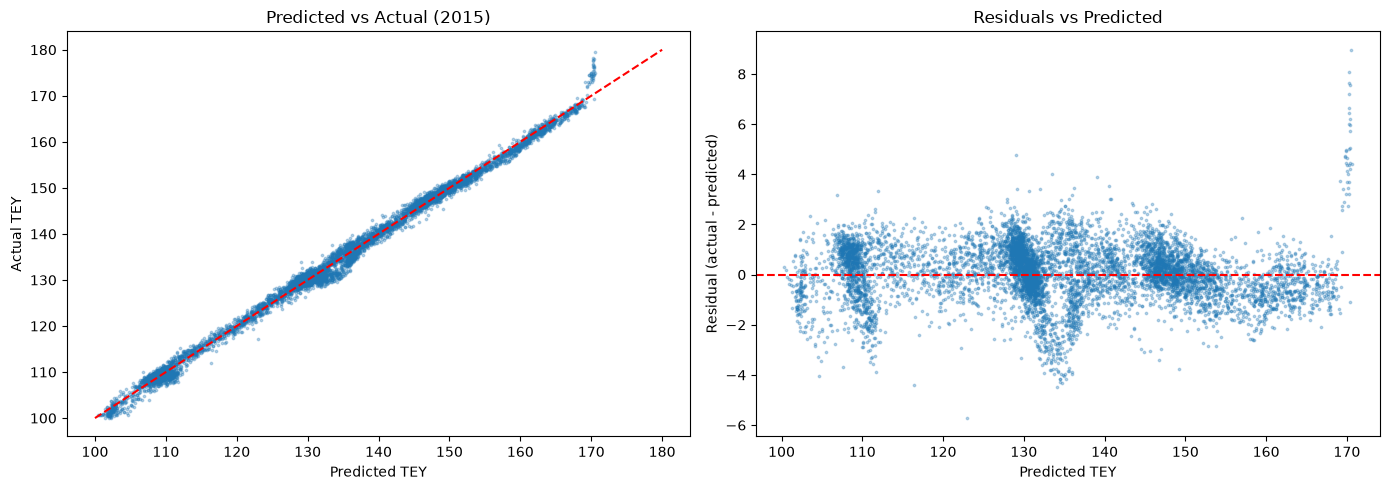

In [16]:
import matplotlib.pyplot as plt

residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual — points should hug the diagonal.
axes[0].scatter(test_pred, y_test, s=3, alpha=0.3)
axes[0].plot([100, 180], [100, 180], "r--")
axes[0].set_xlabel("Predicted TEY")
axes[0].set_ylabel("Actual TEY")
axes[0].set_title("Predicted vs Actual (2015)")

# Residuals vs predicted — should scatter randomly around 0.
axes[1].scatter(test_pred, residuals, s=3, alpha=0.3)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted TEY")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

Save the Pipeline

In [17]:
from joblib import dump, load
from pathlib import Path
import numpy as np

models_dir = Path.cwd().parent / "models"
models_dir.mkdir(exist_ok=True)

artifact = {
    "pipeline": best_model,                 # tuned HGB regressor + scaler
    "feature_columns": feature_columns,     # the 8 operational sensors, in order
    "target": "TEY",
    "model_name": "HistGradientBoostingRegressor",
    "test_rmse": 1.144,
    "test_r2": 0.995,
}

model_path = models_dir / "model.joblib"
dump(artifact, model_path)
print("Saved to", model_path)

# Verify reload reproduces predictions exactly.
loaded = load(model_path)
reloaded_pred = loaded["pipeline"].predict(X_test)
print("Max difference:", np.abs(test_pred - reloaded_pred).max())
print("Identical:", np.allclose(test_pred, reloaded_pred))

Saved to d:\mlbatch3\Project_2\models\model.joblib
Max difference: 0.0
Identical: True


In [ ]:
import sys
from pathlib import Path

# Add project root to the path 
sys.path.insert(0, str(Path.cwd().parent))

from src.features import FEATURE_COLUMNS

# Now the describe() using the actual column list.
print(df[FEATURE_COLUMNS].describe().loc[["min", "max", "mean"]].round(1))

        AT      AP     AH  AFDP  GTEP     TIT    TAT   CDP
min   -6.2   985.8   24.1   2.1  17.7  1000.8  511.0   9.9
max   37.1  1036.6  100.2   7.6  40.7  1100.9  550.6  15.2
mean  17.7  1013.1   77.9   3.9  25.6  1081.4  546.2  12.1
